In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    chi2_contingency, pearsonr, spearmanr,
    normaltest, jarque_bera
)
from numpy.polynomial.polynomial import polyfit, polyval
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Загрузка (если файл уже лежит рядом с ноутбуком)
df = pd.read_csv('SeoulBikeData.csv', encoding='latin1')


print('Размер:', df.shape)
print(df.columns.tolist())
df.head()

from scipy.stats import chisquare, norm


def fmt_p(p):
    """p-value печатается честно: ниже ~1e-308 double обнуляется, это не настоящий ноль."""
    if not np.isfinite(p):
        return 'н/д'
    if p < 1e-300:
        return '< 1e-300'
    return f'{p:.4e}'


def resid_mean_note(resid):
    """Среднее остатков МНК равно нулю с точностью до округления; показываем масштаб."""
    m = resid.mean()
    scale = np.abs(resid).mean()
    return f'{m:.3e} (при среднем |остатке| {scale:.3f}, т.е. ноль с точностью машинного округления)'


Размер: (8760, 14)
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [2]:
df = df.rename(columns={
    'Rented Bike Count': 'Rented',
    'Temperature(°C)': 'Temp',
    'Humidity(%)': 'Humidity',
    'Wind speed (m/s)': 'Wind',
    'Visibility (10m)': 'Visibility',
    'Dew point temperature(°C)': 'DewPoint',
    'Solar Radiation (MJ/m2)': 'Solar',
    'Rainfall(mm)': 'Rainfall',
    'Snowfall (cm)': 'Snowfall',
    'Functioning Day': 'Functioning'
})

print('Типы данных:')
print(df.dtypes)
print('\nПропуски:')
print(df.isnull().sum())
print('\nКатегориальные:')
print('Seasons:', df['Seasons'].unique())
print('Holiday:', df['Holiday'].unique())
print('Functioning:', df['Functioning'].unique())

Типы данных:
Date            object
Rented           int64
Hour             int64
Temp           float64
Humidity         int64
Wind           float64
Visibility       int64
DewPoint       float64
Solar          float64
Rainfall       float64
Snowfall       float64
Seasons         object
Holiday         object
Functioning     object
dtype: object

Пропуски:
Date           0
Rented         0
Hour           0
Temp           0
Humidity       0
Wind           0
Visibility     0
DewPoint       0
Solar          0
Rainfall       0
Snowfall       0
Seasons        0
Holiday        0
Functioning    0
dtype: int64

Категориальные:
Seasons: ['Winter' 'Spring' 'Summer' 'Autumn']
Holiday: ['No Holiday' 'Holiday']
Functioning: ['Yes' 'No']


In [3]:
num_vars = ['Rented', 'Temp', 'Humidity', 'Hour', 'Solar', 'Wind', 'Visibility']

desc = df[num_vars].describe().T
desc['median'] = df[num_vars].median()
desc['skew'] = df[num_vars].skew()
desc['kurtosis'] = df[num_vars].kurtosis()
desc['mode'] = df[num_vars].mode().iloc[0]

print('Дескриптивная статистика')
display(desc.round(3))

Дескриптивная статистика


,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis,mode
Rented,8760.0,704.602,644.997,0.0,191.00,504.50,1065.25,3556.00,504.50,1.153,0.853,0.0
Temp,8760.0,12.883,11.945,-17.8,3.50,13.70,22.50,39.40,13.70,-0.198,-0.838,19.1
Humidity,8760.0,58.226,20.362,0.0,42.00,57.00,74.00,98.00,57.00,0.060,-0.804,53.0
Hour,8760.0,11.500,6.923,0.0,5.75,11.50,17.25,23.00,11.50,0.000,-1.204,0.0
Solar,8760.0,0.569,0.869,0.0,0.00,0.01,0.93,3.52,0.01,1.504,1.126,0.0
Wind,8760.0,1.725,1.036,0.0,0.90,1.50,2.30,7.40,1.50,0.891,0.727,1.1
Visibility,8760.0,1436.826,608.299,27.0,940.00,1698.00,2000.00,2000.00,1698.00,-0.702,-0.962,2000.0


In [4]:
def normality_report(series, name, alpha=0.05):
    n = len(series)
    k2, p_dag = normaltest(series)
    jb, p_jb = jarque_bera(series)
    skew = series.skew()
    kurt = series.kurtosis()

    print(f'\n--- {name} (n={n}) ---')
    print(f'Среднее: {series.mean():.3f}, Медиана: {series.median():.3f}, Мода: {series.mode().iloc[0]:.3f}')
    print(f'Асимметрия (skew): {skew:.3f}')
    print(f'Эксцесс (kurtosis): {kurt:.3f}')
    print(f"D'Agostino K²: stat={k2:.3f}, p={fmt_p(p_dag)}")
    print(f'Jarque-Bera: stat={jb:.3f}, p={fmt_p(p_jb)}')

    # Критерий согласия Пирсона. Параметры μ и σ оценены по выборке (p = 2),
    # поэтому число степеней свободы df = k − p − 1, где k — число интервалов.
    k_bins = int(np.ceil(1 + 3.322 * np.log10(n)))
    counts, edges = np.histogram(series, bins=k_bins)
    mu, sigma = series.mean(), series.std(ddof=1)
    expected = np.array([
        (norm.cdf(edges[i + 1], mu, sigma) - norm.cdf(edges[i], mu, sigma)) * n
        for i in range(len(edges) - 1)
    ])
    counts, expected = counts.astype(float).tolist(), expected.tolist()
    i = 0
    while i < len(expected):                      # интервалы с E < 5 объединяем с соседним
        if expected[i] < 5 and len(expected) > 1:
            j = i - 1 if i == len(expected) - 1 else i + 1
            a, b = (i, j) if i < j else (j, i)
            counts[a] += counts[b]
            expected[a] += expected[b]
            del counts[b], expected[b]
            i = 0
        else:
            i += 1
    counts, expected = np.array(counts), np.array(expected)
    expected = expected * counts.sum() / expected.sum()
    k_used, n_params = len(counts), 2
    df_chi = k_used - n_params - 1
    if df_chi < 1:
        p_chi2 = np.nan
        print(f'Пирсон χ²: осталось {k_used} интервалов, df = k − p − 1 < 1, тест не применяется')
    else:
        chi2_stat, p_chi2 = chisquare(counts, f_exp=expected, ddof=n_params)
        print(f'Пирсон χ²: stat={chi2_stat:.3f}, df = k − p − 1 = {k_used} − {n_params} − 1 = {df_chi}, p={fmt_p(p_chi2)}')
    chi_ok = np.isnan(p_chi2) or p_chi2 > alpha

    if p_dag > alpha and p_jb > alpha and chi_ok and abs(skew) < 0.5 and abs(kurt) < 1:
        print('СОГЛАСУЕТСЯ с нормальным распределением')
        return True
    else:
        print('НЕ согласуется с нормальным распределением')
        return False

for col in ['Rented', 'Temp', 'Humidity', 'Solar']:
    normality_report(df[col], col)


--- Rented (n=8760) ---
Среднее: 704.602, Медиана: 504.500, Мода: 0.000
Асимметрия (skew): 1.153
Эксцесс (kurtosis): 0.853
D'Agostino K²: stat=1415.733, p=< 1e-300
Jarque-Bera: stat=2206.803, p=< 1e-300
Пирсон χ²: stat=4251.900, df = k − p − 1 = 12 − 2 − 1 = 9, p=< 1e-300
НЕ согласуется с нормальным распределением

--- Temp (n=8760) ---
Среднее: 12.883, Медиана: 13.700, Мода: 19.100
Асимметрия (skew): -0.198
Эксцесс (kurtosis): -0.838
D'Agostino K²: stat=944.207, p=9.2930e-206
Jarque-Bera: stat=313.721, p=7.5210e-69
Пирсон χ²: stat=519.847, df = k − p − 1 = 15 − 2 − 1 = 12, p=1.3188e-103
НЕ согласуется с нормальным распределением

--- Humidity (n=8760) ---
Среднее: 58.226, Медиана: 57.000, Мода: 53.000
Асимметрия (skew): 0.060
Эксцесс (kurtosis): -0.804
D'Agostino K²: stat=759.623, p=1.1221e-165
Jarque-Bera: stat=240.997, p=4.6584e-53
Пирсон χ²: stat=754.252, df = k − p − 1 = 15 − 2 − 1 = 12, p=1.0600e-153
НЕ согласуется с нормальным распределением

--- Solar (n=8760) ---
Среднее: 0.5

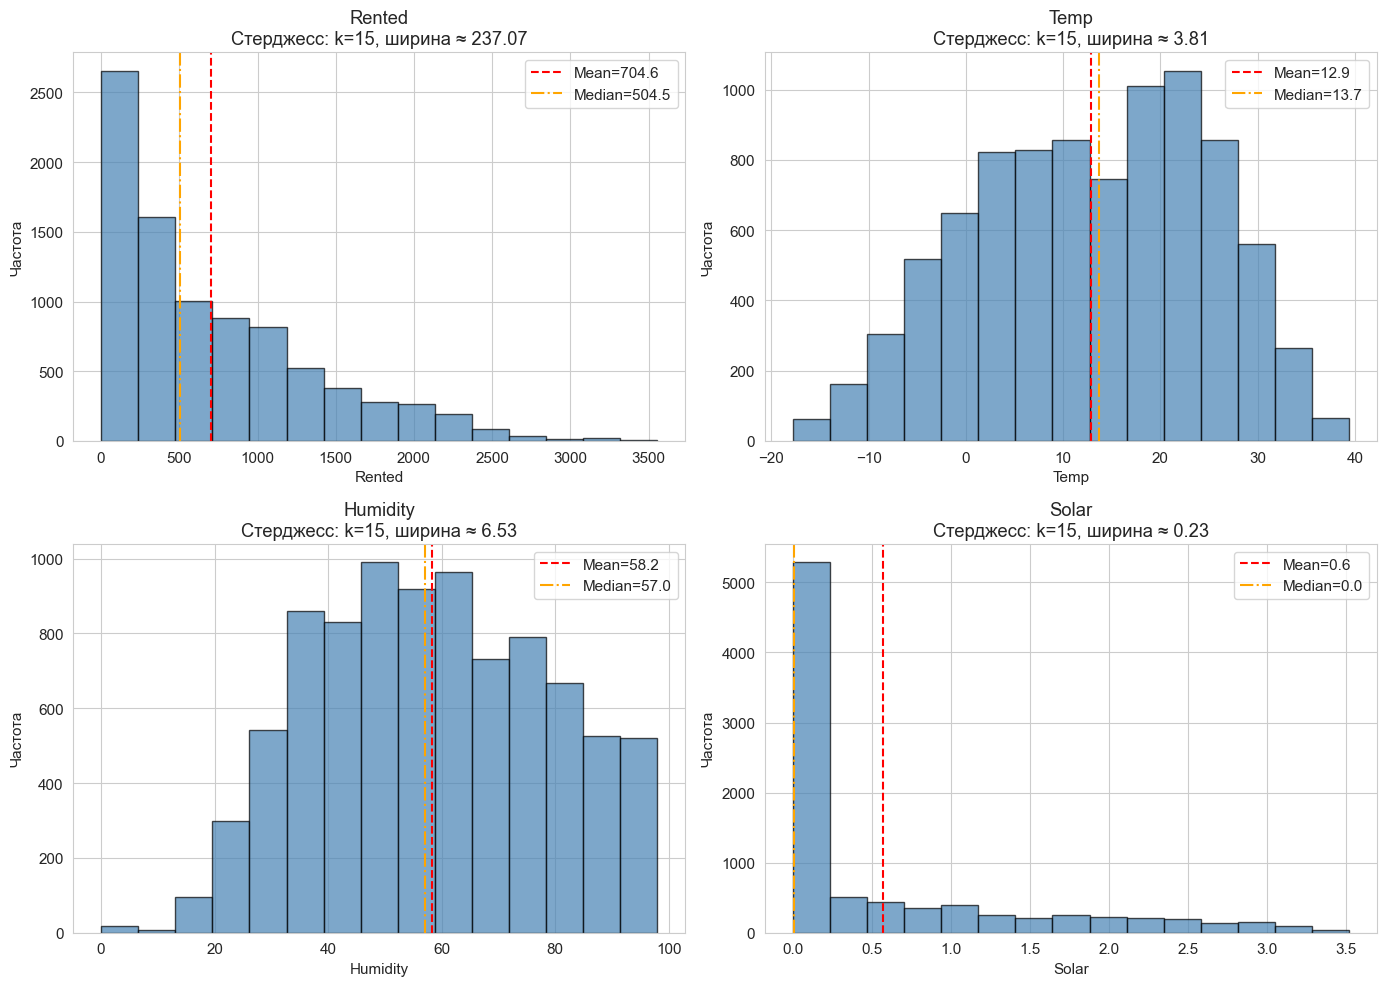

n = 8760 → k = 15


In [5]:
def sturges_bins(series):
    """k = 1 + 3.322 * log10(n)"""
    n = len(series)
    k = int(np.ceil(1 + 3.322 * np.log10(n)))
    return k

vars_for_hist = ['Rented', 'Temp', 'Humidity', 'Solar']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, vars_for_hist):
    k = sturges_bins(df[col])
    data_min, data_max = df[col].min(), df[col].max()
    bin_width = (data_max - data_min) / k

    ax.hist(df[col], bins=k, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'{col}\nСтерджесс: k={k}, ширина ≈ {bin_width:.2f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')
    ax.axvline(df[col].mean(), color='red', linestyle='--',
               label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-.',
               label=f'Median={df[col].median():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'n = {len(df)} → k = {sturges_bins(df["Rented"])}')

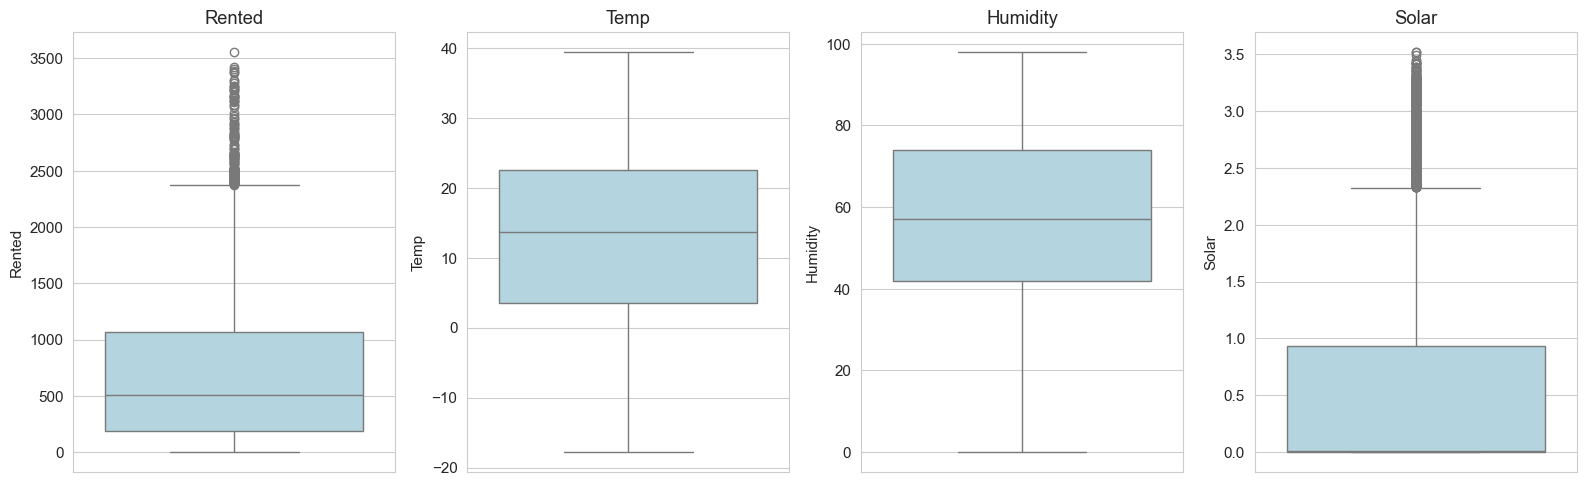

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, vars_for_hist):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [7]:
# Категоризация числовых
df['Rented_cat'] = pd.qcut(df['Rented'], q=3, labels=['Low', 'Medium', 'High'])
df['Temp_cat'] = pd.cut(df['Temp'], bins=[-20, 0, 15, 25, 40],
                        labels=['Cold', 'Cool', 'Warm', 'Hot'])

print('Rented_cat:')
print(df['Rented_cat'].value_counts().sort_index())
print('\nTemp_cat:')
print(df['Temp_cat'].value_counts().sort_index())

Rented_cat:
Rented_cat
Low       2926
Medium    2916
High      2918
Name: count, dtype: int64

Temp_cat:
Temp_cat
Cold    1454
Cool    3185
Warm    2619
Hot     1502
Name: count, dtype: int64


In [8]:
# Seasons × Rented_cat
ct_seasons = pd.crosstab(df['Seasons'], df['Rented_cat'], margins=True)
print('=== Seasons × Уровень спроса ===')
display(ct_seasons)

ct = pd.crosstab(df['Seasons'], df['Rented_cat'])
chi2, p, dof, expected = chi2_contingency(ct)
r, c = ct.shape
print(f'\nχ² = {chi2:.3f}, df = (r−1)(c−1) = ({r}−1)({c}−1) = {dof}, p = {fmt_p(p)}')
print('Ожидаемые частоты:')
display(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

print('Зависимость значима' if p < 0.05 else 'Независимость не отвергается')

=== Seasons × Уровень спроса ===


Rented_cat,Low,Medium,High,All
Seasons,,,,
Autumn,582,637,965,2184
Spring,662,752,794,2208
Summer,264,790,1154,2208
Winter,1418,737,5,2160
All,2926,2916,2918,8760



χ² = 2059.957, df = (r−1)(c−1) = (4−1)(3−1) = 6, p = < 1e-300
Ожидаемые частоты:


Rented_cat,Low,Medium,High
Seasons,,,
Autumn,729.5,727.0,727.5
Spring,737.5,735.0,735.5
Summer,737.5,735.0,735.5
Winter,721.5,719.0,719.5


Зависимость значима


In [9]:
# Holiday × Rented_cat
ct_holiday = pd.crosstab(df['Holiday'], df['Rented_cat'], margins=True)
print('Holiday и Уровень спроса')
display(ct_holiday)

ct2 = pd.crosstab(df['Holiday'], df['Rented_cat'])
chi2_h, p_h, dof_h, _ = chi2_contingency(ct2)
r, c = ct2.shape
print(f'\nχ² = {chi2_h:.3f}, df = (r−1)(c−1) = ({r}−1)({c}−1) = {dof_h}, p = {fmt_p(p_h)}')
print('Зависимость значима' if p_h < 0.05 else 'Независимость не отвергается')

Holiday и Уровень спроса


Rented_cat,Low,Medium,High,All
Holiday,,,,
Holiday,232,101,99,432
No Holiday,2694,2815,2819,8328
All,2926,2916,2918,8760



χ² = 84.211, df = (r−1)(c−1) = (2−1)(3−1) = 2, p = 5.1744e-19
Зависимость значима


In [10]:
# Temp_cat × Rented_cat
ct_temp = pd.crosstab(df['Temp_cat'], df['Rented_cat'], margins=True)
print('Температура и Уровень спроса')
display(ct_temp)

ct3 = pd.crosstab(df['Temp_cat'], df['Rented_cat'])
chi2_t, p_t, dof_t, _ = chi2_contingency(ct3)
r, c = ct3.shape
print(f'\nχ² = {chi2_t:.3f}, df = (r−1)(c−1) = ({r}−1)({c}−1) = {dof_t}, p = {fmt_p(p_t)}')
print('→ Зависимость значима' if p_t < 0.05 else '→ Независимость не отвергается')

Температура и Уровень спроса


Rented_cat,Low,Medium,High,All
Temp_cat,,,,
Cold,1119,328,7,1454
Cool,1140,1450,595,3185
Warm,593,647,1379,2619
Hot,74,491,937,1502
All,2926,2916,2918,8760



χ² = 2888.837, df = (r−1)(c−1) = (4−1)(3−1) = 6, p = < 1e-300
→ Зависимость значима


In [11]:
corr_vars = ['Rented', 'Temp', 'Humidity', 'Hour', 'Solar',
             'Wind', 'Visibility', 'DewPoint', 'Rainfall', 'Snowfall']

pearson_corr = df[corr_vars].corr(method='pearson')
spearman_corr = df[corr_vars].corr(method='spearman')

print('=== Пирсон ===')
display(pearson_corr.round(3))
print('\n=== Спирмен ===')
display(spearman_corr.round(3))

=== Пирсон ===


,Rented,Temp,Humidity,Hour,Solar,Wind,Visibility,DewPoint,Rainfall,Snowfall
Rented,1.000,0.539,-0.200,0.410,0.262,0.121,0.199,0.380,-0.123,-0.142
Temp,0.539,1.000,0.159,0.124,0.354,-0.036,0.035,0.913,0.050,-0.218
Humidity,-0.200,0.159,1.000,-0.242,-0.462,-0.337,-0.543,0.537,0.236,0.108
Hour,0.410,0.124,-0.242,1.000,0.145,0.285,0.099,0.003,0.009,-0.022
Solar,0.262,0.354,-0.462,0.145,1.000,0.332,0.150,0.094,-0.074,-0.072
Wind,0.121,-0.036,-0.337,0.285,0.332,1.000,0.172,-0.176,-0.020,-0.004
Visibility,0.199,0.035,-0.543,0.099,0.150,0.172,1.000,-0.177,-0.168,-0.122
DewPoint,0.380,0.913,0.537,0.003,0.094,-0.176,-0.177,1.000,0.126,-0.151
Rainfall,-0.123,0.050,0.236,0.009,-0.074,-0.020,-0.168,0.126,1.000,0.008
Snowfall,-0.142,-0.218,0.108,-0.022,-0.072,-0.004,-0.122,-0.151,0.008,1.000



=== Спирмен ===


,Rented,Temp,Humidity,Hour,Solar,Wind,Visibility,DewPoint,Rainfall,Snowfall
Rented,1.000,0.565,-0.221,0.389,0.382,0.148,0.176,0.374,-0.282,-0.221
Temp,0.565,1.000,0.154,0.121,0.328,0.011,0.046,0.912,0.072,-0.307
Humidity,-0.221,0.154,1.000,-0.251,-0.438,-0.355,-0.483,0.521,0.368,0.050
Hour,0.389,0.121,-0.251,1.000,0.209,0.307,0.094,0.003,-0.026,-0.032
Solar,0.382,0.328,-0.438,0.209,1.000,0.363,0.049,0.094,-0.091,-0.077
Wind,0.148,0.011,-0.355,0.307,0.363,1.000,0.154,-0.128,-0.052,0.029
Visibility,0.176,0.046,-0.483,0.094,0.049,0.154,1.000,-0.129,-0.232,-0.074
DewPoint,0.374,0.912,0.521,0.003,0.094,-0.128,-0.129,1.000,0.213,-0.249
Rainfall,-0.282,0.072,0.368,-0.026,-0.091,-0.052,-0.232,0.213,1.000,0.002
Snowfall,-0.221,-0.307,0.050,-0.032,-0.077,0.029,-0.074,-0.249,0.002,1.000


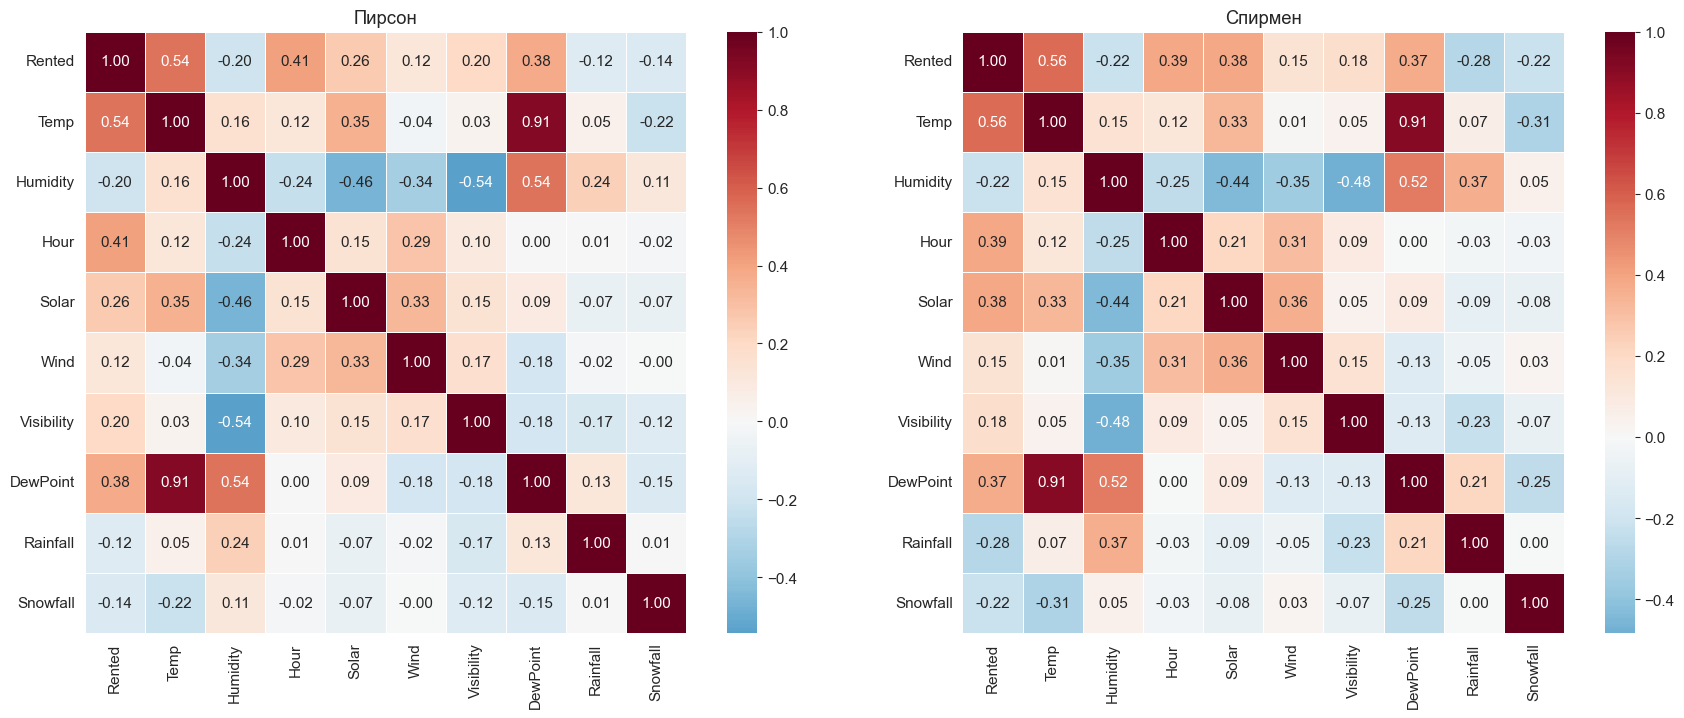

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Пирсон')

sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Спирмен')

plt.tight_layout()
plt.show()

In [13]:
print(f'{"Переменная":<15} {"Pearson r":>10} {"p":>12} {"Spearman ρ":>12} {"p":>12} {"Сила":>12}')
print('-' * 75)

for col in corr_vars:
    if col == 'Rented':
        continue
    r_p, p_p = pearsonr(df['Rented'], df[col])
    r_s, p_s = spearmanr(df['Rented'], df[col])

    abs_r = abs(r_s)
    if abs_r >= 0.7:
        strength = 'сильная'
    elif abs_r >= 0.4:
        strength = 'средняя'
    elif abs_r >= 0.2:
        strength = 'слабая'
    else:
        strength = 'очень слабая'

    sig = '***' if p_s < 0.001 else ('**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns'))
    print(f'{col:<15} {r_p:>10.3f} {fmt_p(p_p):>12} {r_s:>12.3f} {fmt_p(p_s):>12} {strength:>10} {sig}')

Переменная       Pearson r            p   Spearman ρ            p         Сила
---------------------------------------------------------------------------
Temp                 0.539     < 1e-300        0.565     < 1e-300    средняя ***
Humidity            -0.200   1.4751e-79       -0.221   3.7026e-97     слабая ***
Hour                 0.410     < 1e-300        0.389     < 1e-300     слабая ***
Solar                0.262  2.7804e-137        0.382     < 1e-300     слабая ***
Wind                 0.121   5.5446e-30        0.148   8.0739e-44 очень слабая ***
Visibility           0.199   3.6727e-79        0.176   4.5587e-62 очень слабая ***
DewPoint             0.380  1.3256e-298        0.374  8.4613e-289     слабая ***
Rainfall            -0.123   6.4628e-31       -0.282  3.5352e-160     слабая ***
Snowfall            -0.142   1.3980e-40       -0.221   3.6982e-97     слабая ***


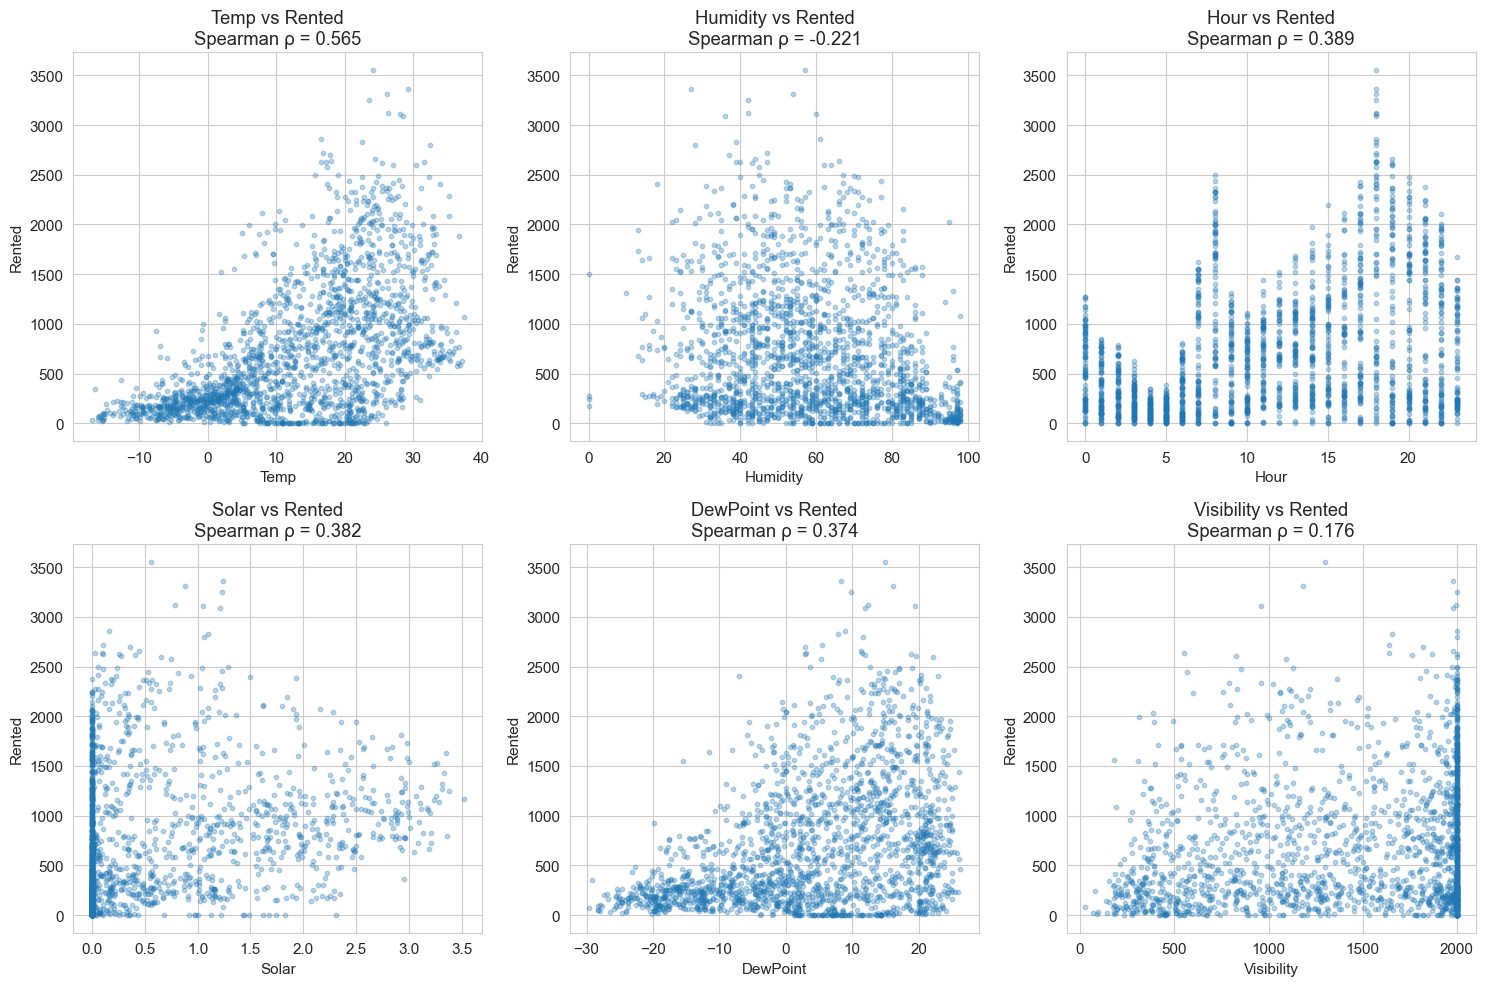

In [14]:
# Диаграммы рассеяния
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pairs = [('Temp', 'Rented'), ('Humidity', 'Rented'), ('Hour', 'Rented'),
         ('Solar', 'Rented'), ('DewPoint', 'Rented'), ('Visibility', 'Rented')]

for ax, (x, y) in zip(axes.ravel(), pairs):
    sample = df.sample(min(2000, len(df)), random_state=42)
    ax.scatter(sample[x], sample[y], alpha=0.3, s=10)
    r_s, _ = spearmanr(df[x], df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}\nSpearman ρ = {r_s:.3f}')

plt.tight_layout()
plt.show()

Таблица (ложная корреляция):


,Year,Cage_Films,Pool_Drownings
0,1999,2,109
1,2000,2,102
2,2001,2,102
3,2002,3,98
4,2003,1,85
5,2004,1,95
6,2005,2,96
7,2006,3,98
8,2007,4,123
9,2008,1,94


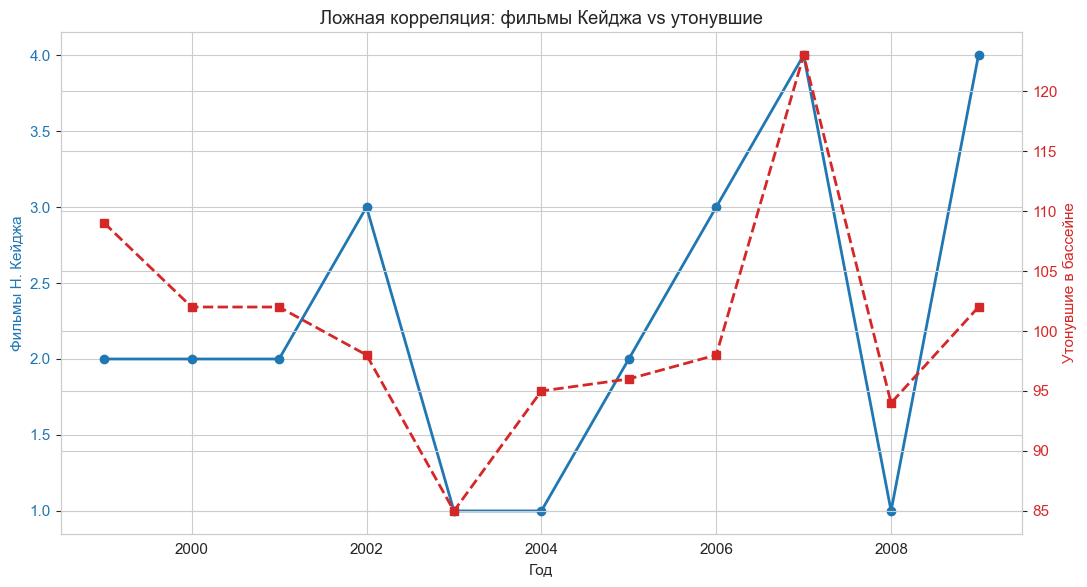

Исходная корреляция: r = 0.666, p = 2.5269e-02


In [15]:
# 9.1 Таблица данных + диаграмма с двумя осями
years = np.arange(1999, 2010)
cage_films = np.array([2, 2, 2, 3, 1, 1, 2, 3, 4, 1, 4])
drownings  = np.array([109, 102, 102, 98, 85, 95, 96, 98, 123, 94, 102])

spurious = pd.DataFrame({
    'Year': years,
    'Cage_Films': cage_films,
    'Pool_Drownings': drownings
})
print('Таблица (ложная корреляция):')
display(spurious)

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.set_xlabel('Год')
ax1.set_ylabel('Фильмы Н. Кейджа', color='tab:blue')
ax1.plot(spurious['Year'], spurious['Cage_Films'], 'o-', color='tab:blue', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Утонувшие в бассейне', color='tab:red')
ax2.plot(spurious['Year'], spurious['Pool_Drownings'], 's--', color='tab:red', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Ложная корреляция: фильмы Кейджа vs утонувшие')
fig.tight_layout()
plt.show()

r_spur, p_spur = pearsonr(spurious['Cage_Films'], spurious['Pool_Drownings'])
print(f'Исходная корреляция: r = {r_spur:.3f}, p = {fmt_p(p_spur)}')


Выбор степени по скорректированному R²:
Cage: d=1: R²=0.126, R²adj=0.029, d=2: R²=0.207, R²adj=0.008, d=3: R²=0.208, R²adj=-0.132
Drownings: d=1: R²=0.000, R²adj=-0.111, d=2: R²=0.164, R²adj=-0.045, d=3: R²=0.315, R²adj=0.022


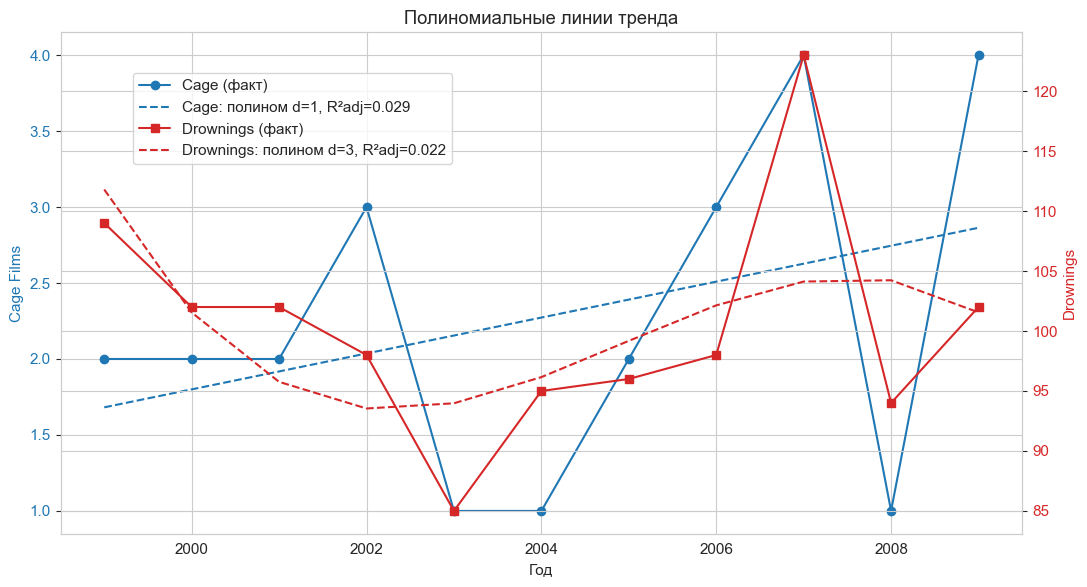

Cage (d=1): y = 0.1182·t + 1.6818
Drownings (d=3): y = − 0.1511·t^3 + 2.6876·t^2 − 12.7883·t + 111.7972


In [16]:
# 9.2 Линии тренда. Степень 1–3 выбирается по скорректированному R².
x = np.arange(len(years))

def select_poly_trend(x, y, max_degree=3):
    rows = []
    n = len(y)
    for degree in range(1, max_degree + 1):
        coef = np.polyfit(x, y, degree)
        fitted = np.polyval(coef, x)
        r2 = 1 - np.sum((y - fitted) ** 2) / np.sum((y - np.mean(y)) ** 2)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - degree - 1)
        rows.append((degree, coef, fitted, r2, adj_r2))
    best = max(rows, key=lambda row: row[4])
    return best, rows

def poly_equation(coef):
    degree = len(coef) - 1
    parts = []
    for i, value in enumerate(coef):
        power = degree - i
        sign = '+' if value >= 0 and parts else ('−' if value < 0 else '')
        term = f'{abs(value):.4f}' if power == 0 else (
            f'{abs(value):.4f}·t' if power == 1 else f'{abs(value):.4f}·t^{power}'
        )
        parts.append(f'{sign} {term}'.strip())
    return ' '.join(parts)

(degree_c, coef_c, trend_c, r2_c, adj_c), candidates_c = select_poly_trend(x, cage_films)
(degree_d, coef_d, trend_d, r2_d, adj_d), candidates_d = select_poly_trend(x, drownings)

print('Выбор степени по скорректированному R²:')
for name, rows in [('Cage', candidates_c), ('Drownings', candidates_d)]:
    print(name + ': ' + ', '.join(
        f'd={degree}: R²={r2:.3f}, R²adj={adj:.3f}'
        for degree, _, _, r2, adj in rows
    ))

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(years, cage_films, 'o-', color='tab:blue', label='Cage (факт)')
ax1.plot(years, trend_c, '--', color='tab:blue',
         label=f'Cage: полином d={degree_c}, R²adj={adj_c:.3f}')
ax1.set_ylabel('Cage Films', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(years, drownings, 's-', color='tab:red', label='Drownings (факт)')
ax2.plot(years, trend_d, '--', color='tab:red',
         label=f'Drownings: полином d={degree_d}, R²adj={adj_d:.3f}')
ax2.set_ylabel('Drownings', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xlabel('Год')
ax1.set_title('Полиномиальные линии тренда')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

print(f'Cage (d={degree_c}): y = {poly_equation(coef_c)}')
print(f'Drownings (d={degree_d}): y = {poly_equation(coef_d)}')


In [17]:
# 9.3–9.5 Предсказания, остатки, стандартизированные остатки
spurious['Cage_pred'] = trend_c
spurious['Drown_pred'] = trend_d
spurious['Cage_resid'] = spurious['Cage_Films'] - spurious['Cage_pred']
spurious['Drown_resid'] = spurious['Pool_Drownings'] - spurious['Drown_pred']
spurious['Cage_std_resid'] = (
    (spurious['Cage_resid'] - spurious['Cage_resid'].mean()) / spurious['Cage_resid'].std()
)
spurious['Drown_std_resid'] = (
    (spurious['Drown_resid'] - spurious['Drown_resid'].mean()) / spurious['Drown_resid'].std()
)

print('Таблица с остатками:')
display(spurious.round(3))

Таблица с остатками:


,Year,Cage_Films,Pool_Drownings,Cage_pred,Drown_pred,Cage_resid,Drown_resid,Cage_std_resid,Drown_std_resid
0,1999,2,109,1.682,111.797,0.318,-2.797,0.308,-0.350
1,2000,2,102,1.800,101.545,0.200,0.455,0.194,0.057
2,2001,2,102,1.918,95.762,0.082,6.238,0.079,0.781
3,2002,3,98,2.036,93.541,0.964,4.459,0.934,0.559
4,2003,1,85,2.155,93.974,-1.155,-8.974,-1.119,-1.124
5,2004,1,95,2.273,96.156,-1.273,-1.156,-1.234,-0.145
6,2005,2,96,2.391,99.179,-0.391,-3.179,-0.379,-0.398
7,2006,3,98,2.509,102.138,0.491,-4.138,0.476,-0.518
8,2007,4,123,2.627,104.124,1.373,18.876,1.330,2.365
9,2008,1,94,2.745,104.231,-1.745,-10.231,-1.692,-1.282


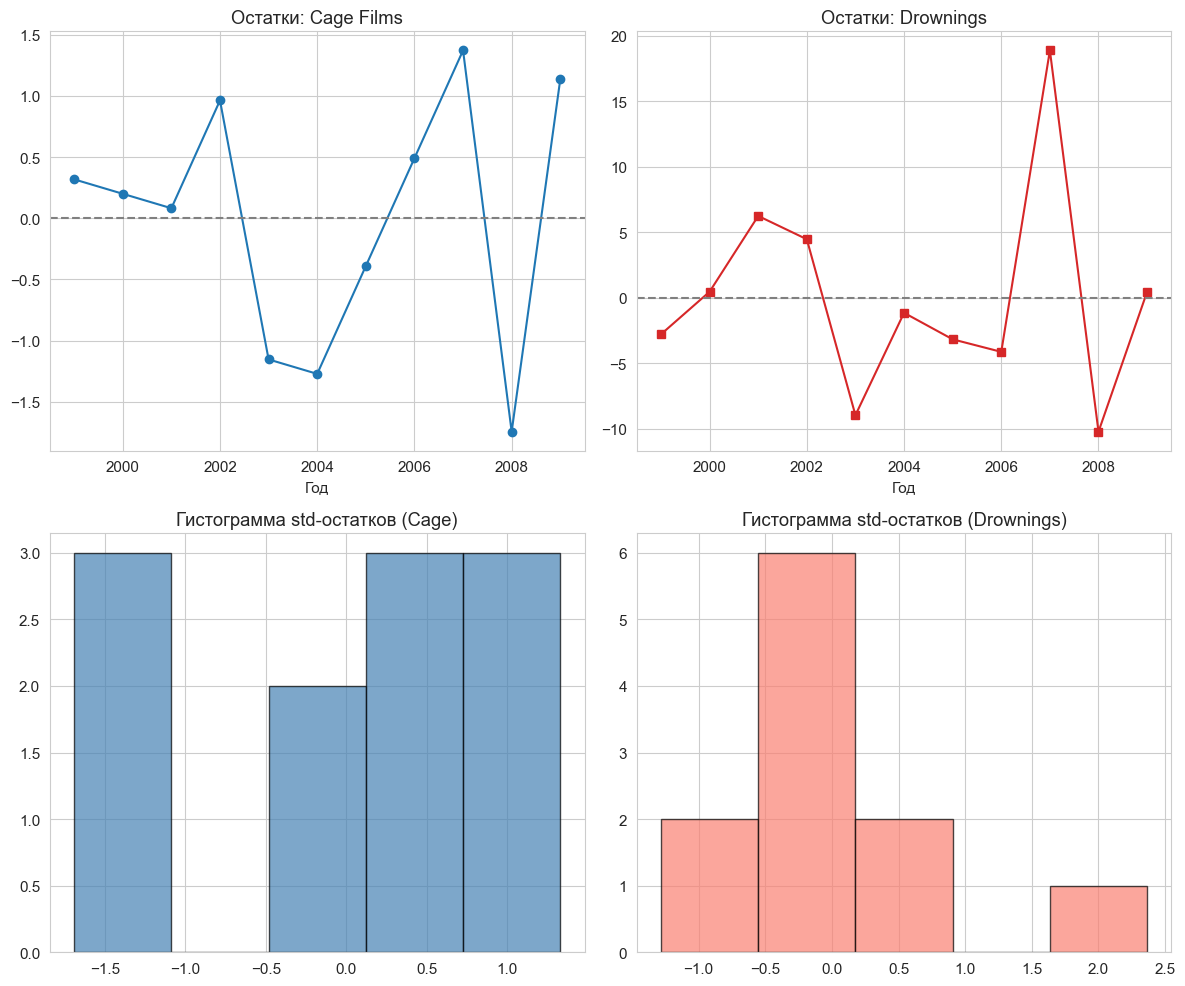

In [18]:
# 9.6 График остатков + гистограммы
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(years, spurious['Cage_resid'], 'o-', color='tab:blue')
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Остатки: Cage Films')
axes[0, 0].set_xlabel('Год')

axes[0, 1].plot(years, spurious['Drown_resid'], 's-', color='tab:red')
axes[0, 1].axhline(0, color='gray', linestyle='--')
axes[0, 1].set_title('Остатки: Drownings')
axes[0, 1].set_xlabel('Год')

axes[1, 0].hist(spurious['Cage_std_resid'], bins=5, edgecolor='black',
                color='steelblue', alpha=0.7)
axes[1, 0].set_title('Гистограмма std-остатков (Cage)')

axes[1, 1].hist(spurious['Drown_std_resid'], bins=5, edgecolor='black',
                color='salmon', alpha=0.7)
axes[1, 1].set_title('Гистограмма std-остатков (Drownings)')

plt.tight_layout()
plt.show()

In [19]:
# 9.7–9.8 Корреляция остатков + значимость
r_resid, p_resid = pearsonr(spurious['Cage_resid'], spurious['Drown_resid'])
print(f'Корреляция остатков: r = {r_resid:.4f}, p = {fmt_p(p_resid)}')

if p_resid > 0.05:
    print('→ Корреляция остатков НЕ значима. После удаления тренда связь исчезла.')
else:
    print('→ Корреляция остатков всё ещё значима.')

print(f'\nИсходная корреляция рядов: r = {r_spur:.3f}, p = {fmt_p(p_spur)}')


Корреляция остатков: r = 0.7204, p = 1.2392e-02
→ Корреляция остатков всё ещё значима.

Исходная корреляция рядов: r = 0.666, p = 2.5269e-02


## ЛР 1.2. Регрессионный анализ

Пункты 1–3 (описание данных, дескриптивная статистика, гистограммы Стерджесса) выполнены выше на том же массиве Seoul Bike. Дальше — пункты 4–12.

Зависимая переменная `Rented` — число аренд за час, целое и неотрицательное, поэтому по типу переменной естественна пуассоновская регрессия. Линейную модель с фиктивными переменными строим тоже: лабораторная просит оба варианта. Точку росы не включаем: она сильно коррелирует с температурой (мультиколлинеарность). Базовые уровни фиктивных переменных: зима, не праздник, рабочий день станции.


In [20]:
# 4–5, 8–10. Линейная модель с фиктивными переменными, МНК

import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

def short_term(name):
    repl = {
        "C(Seasons, Treatment(reference='Winter'))[T.": "Season:",
        "C(Holiday, Treatment(reference='No Holiday'))[T.": "Holiday:",
        "C(Functioning, Treatment(reference='Yes'))[T.": "Functioning:",
        "C(sex, Treatment(reference='female'))[T.": "sex:",
        "C(smoker, Treatment(reference='no'))[T.": "smoker:",
        "C(region, Treatment(reference='northeast'))[T.": "region:",
    }
    for old, new in repl.items():
        name = name.replace(old, new)
    return name.replace("]", "")

def write_equation(model, left):
    chunks = []
    for name, coef in model.params.items():
        label = "1" if name == "Intercept" else short_term(name)
        if not chunks:
            chunks.append(f"{coef:.4f}" if name == "Intercept" else f"{coef:.4f}·{label}")
        else:
            sign = "+" if coef >= 0 else "−"
            chunks.append(f" {sign} {abs(coef):.4f}·{label}")
    print(left + " = " + "".join(chunks))

def ols_quality(model, y_name):
    n = int(model.nobs)
    k = int(model.df_model)
    r2 = model.rsquared
    r2_adj = 1 - (1 - r2) * n / (n - k - 1)
    f_crit = stats.f.ppf(0.95, model.df_model, model.df_resid)
    t_crit = stats.t.ppf(0.975, model.df_resid)
    df_resid = n - k - 1
    print(f"R² = {r2:.4f}   R²_скорр = {r2_adj:.4f}   n = {n}, k = {k}")
    print(f"Степени свободы остатков: df = n − k − 1 = {n} − {k} − 1 = {df_resid}")
    print(f"F = {model.fvalue:.3f}, F_крит(0.05; {k}, {int(model.df_resid)}) = {f_crit:.3f}, p = {fmt_p(model.f_pvalue)}")
    if model.fvalue > f_crit:
        print("Уравнение в целом значимо: H0 (все β = 0) отвергается.")
    else:
        print("Уравнение в целом не значимо.")
    if r2 >= 0.75:
        print("По порогу со слайда диагностики (R² ≥ 0.75) модель приемлема.")
    else:
        print("По порогу со слайда диагностики (R² ≥ 0.75) модель слабая: доля объяснённой вариации меньше 75%.")
    print(f"\nЗначимость коэффициентов, t_крит = {t_crit:.3f}, df = {int(model.df_resid)}")
    print(f"{'Коэффициент':<28} {'оценка':>12} {'t':>10} {'p':>12} {'вывод':>12}")
    for name, coef in model.params.items():
        t = model.tvalues[name]
        p = model.pvalues[name]
        verdict = "значим" if abs(t) > t_crit else "не значим"
        print(f"{short_term(name):<28} {coef:12.4f} {t:10.2f} {fmt_p(p):>12} {verdict:>12}")
    write_equation(model, y_name)

def influence_table(model, frame, y_name, factors):
    y = frame[y_name]
    sy = y.std(ddof=1)
    print("\nСредняя эластичность, бета- и дельта-коэффициенты (количественные факторы)")
    print(f"{'Фактор':<12} {'Э':>8} {'β':>8} {'Δ':>8}")
    deltas = []
    for col in factors:
        b = model.params[col]
        elast = b * frame[col].mean() / y.mean()
        beta = b * frame[col].std(ddof=1) / sy
        delta = frame[col].corr(y) * beta / model.rsquared
        deltas.append(delta)
        print(f"{col:<12} {elast:8.3f} {beta:8.3f} {delta:8.3f}")
    print(f"Сумма дельта-коэффициентов по этим факторам: {sum(deltas):.3f}")

def partial_corr(y, x1, x2):
    r_y1 = np.corrcoef(y, x1)[0, 1]
    r_y2 = np.corrcoef(y, x2)[0, 1]
    r_12 = np.corrcoef(x1, x2)[0, 1]
    num = r_y1 - r_y2 * r_12
    den = np.sqrt((1 - r_y2 ** 2) * (1 - r_12 ** 2))
    return num / den, r_y1

def residual_report(y, fitted, title, ordered):
    resid = np.asarray(y) - np.asarray(fitted)
    std_resid = (resid - resid.mean()) / resid.std(ddof=1)
    print(f"\n=== Остатки: {title} ===")
    mae = np.mean(np.abs(resid))
    rmse = np.sqrt(np.mean(resid ** 2))
    print(f"Среднее остатков = {resid.mean():.3e}")
    print(f"MAE = {mae:.3f}, RMSE = {rmse:.3f}")
    print("Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой "
          "(точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков.")
    q1, q2 = np.quantile(fitted, [1 / 3, 2 / 3])
    v_low = resid[fitted <= q1].var(ddof=1)
    v_mid = resid[(fitted > q1) & (fitted <= q2)].var(ddof=1)
    v_high = resid[fitted > q2].var(ddof=1)
    print(f"Дисперсия остатков по третям прогноза: {v_low:.1f} | {v_mid:.1f} | {v_high:.1f}")
    ratio = max(v_low, v_mid, v_high) / min(v_low, v_mid, v_high)
    if ratio < 2:
        print("Дисперсия остатков примерно постоянна.")
    else:
        print(f"Дисперсия остатков не постоянна (разброс третей в {ratio:.1f} раза): гетероскедастичность.")
    dw = durbin_watson(resid)
    print(f"Дарбин–Уотсон DW = {dw:.3f} (около 2 — остатки не коррелируют).")
    if not ordered:
        print("Наблюдения не являются временным рядом, DW здесь вспомогательный.")
    k = int(np.ceil(1 + 3.322 * np.log10(len(resid))))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(np.arange(len(resid)), resid, s=8, alpha=0.25, color="navy")
    axes[0].axhline(0, color="gray", linestyle="--")
    axes[0].set_title(f"Остатки: {title}")
    axes[0].set_xlabel("Номер наблюдения")
    axes[0].set_ylabel("Остаток")
    axes[1].hist(std_resid, bins=k, edgecolor="black", color="steelblue", alpha=0.8)
    axes[1].set_title(f"Стандартизированные остатки, k={k}")
    axes[1].set_xlabel("std-остаток")
    plt.tight_layout()
    plt.show()
    return resid

y_name = "Rented"
numeric_factors = ["Temp", "Humidity", "Hour"]
lin_formula = (
    "Rented ~ Temp + Humidity + Hour"
    " + C(Seasons, Treatment(reference='Winter'))"
    " + C(Holiday, Treatment(reference='No Holiday'))"
    " + C(Functioning, Treatment(reference='Yes'))"
)
lin = smf.ols(lin_formula, data=df).fit()
print("Линейная регрессия, метод наименьших квадратов")
ols_quality(lin, "Rented")
influence_table(lin, df, "Rented", numeric_factors)
r_part, r_pair = partial_corr(df["Rented"], df["Temp"], df["Hour"])
print(f"\nПарная корреляция Rented–Temp = {r_pair:.3f}")
print(f"Частная корреляция Rented–Temp при исключении Hour = {r_part:.3f}")


Линейная регрессия, метод наименьших квадратов
R² = 0.5320   R²_скорр = 0.5315   n = 8760, k = 8
Степени свободы остатков: df = n − k − 1 = 8760 − 8 − 1 = 8751
F = 1243.329, F_крит(0.05; 8, 8751) = 1.939, p = < 1e-300
Уравнение в целом значимо: H0 (все β = 0) отвергается.
По порогу со слайда диагностики (R² ≥ 0.75) модель слабая: доля объяснённой вариации меньше 75%.

Значимость коэффициентов, t_крит = 1.960, df = 8751
Коэффициент                        оценка          t            p        вывод
Intercept                        338.1857      17.52   1.3094e-67       значим
Season:Autumn                    390.4468      20.01   3.6445e-87       значим
Season:Spring                    234.6591      12.49   1.8025e-35       значим
Season:Summer                    258.9344       9.27   2.2961e-20       значим
Holiday:Holiday                 -111.9991      -5.09   3.7073e-07       значим
Functioning:No                  -925.2514     -34.08  3.8137e-239       значим
Temp                    


=== Остатки: линейная модель ===
Среднее остатков = 3.687e-12
MAE = 330.947, RMSE = 441.234
Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой (точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков.
Дисперсия остатков по третям прогноза: 68038.1 | 183314.7 | 305989.7
Дисперсия остатков не постоянна (разброс третей в 4.5 раза): гетероскедастичность.
Дарбин–Уотсон DW = 0.470 (около 2 — остатки не коррелируют).


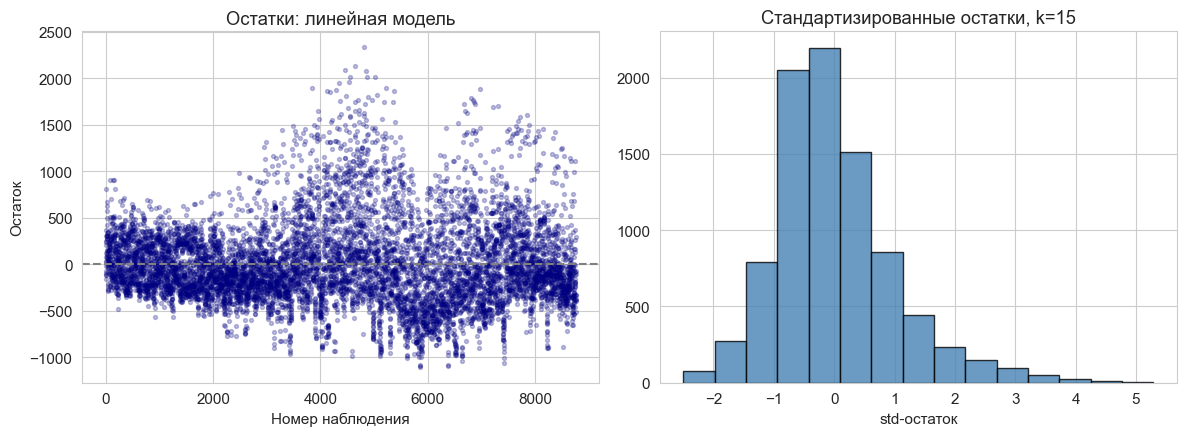

Нулевое среднее не означает идеальную модель: это алгебраическое свойство МНК с константой. Смотрите MAE, RMSE, дисперсию и график.
Часовые наблюдения идут подряд, поэтому DW показывает автокорреляцию остатков, если он далёк от 2.


In [21]:
# 6–7. Остатки линейной модели
residual_report(df[y_name], lin.fittedvalues, "линейная модель", ordered=True)
print("Нулевое среднее не означает идеальную модель: это алгебраическое свойство МНК с константой. Смотрите MAE, RMSE, дисперсию и график.")
print("Часовые наблюдения идут подряд, поэтому DW показывает автокорреляцию остатков, если он далёк от 2.")


Сходимость оптимизации: True
Пуассоновская регрессия: ln(λ) = Xβ, λ = exp(Xβ). Оценки — метод максимального правдоподобия.
ln(λ) = 5.3892 + 1.0129·Season:Autumn + 0.8051·Season:Spring + 0.8310·Season:Summer − 0.1716·Holiday:Holiday − 85.6531·Functioning:No + 0.0281·Temp − 0.0103·Humidity + 0.0463·Hour

Псевдо-R² = 1 − lnL / lnL0 = 0.6281
Обычного R² и F-критерия у пуассоновской модели нет: значимость уравнения — отношение правдоподобия к нулевой модели.
LR = 3169565.3, χ²_крит(0.05, df=8) = 15.507, p = < 1e-300
Модель значима относительно константы.

Коэффициенты, z-тест Вальда, z_крит = 1.960
Коэффициент                        оценка          z            p
Intercept                          5.3892    2633.10     < 1e-300
Season:Autumn                      1.0129     494.85     < 1e-300
Season:Spring                      0.8051     397.15     < 1e-300
Season:Summer                      0.8310     311.90     < 1e-300
Holiday:Holiday                   -0.1716     -77.75     < 1e-300
Fun

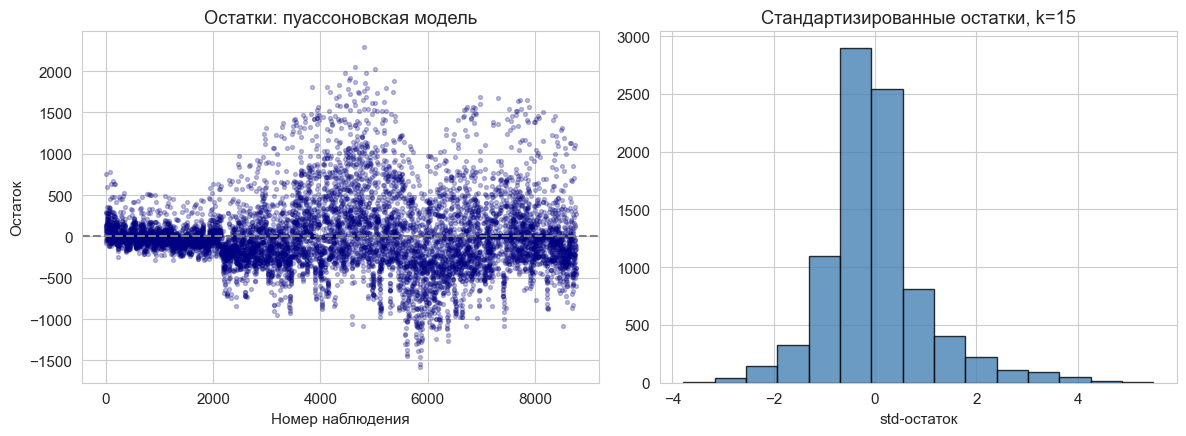

array([ 124.68641521,   71.06492535,   37.10776438, ..., -455.28328404,
       -450.81928839, -602.47317409])

In [22]:
# 11. Пуассоновская регрессия, ММП. Пункты 6–10 для этой модели.
poi = smf.poisson(lin_formula, data=df).fit(disp=False, method='newton', maxiter=1000)
print(f"Сходимость оптимизации: {poi.mle_retvals['converged']}")
mu = poi.predict()
phi = np.sum((df[y_name] - mu) ** 2 / mu) / poi.df_resid
pseudo_r2 = 1 - poi.llf / poi.llnull
chi_crit = stats.chi2.ppf(0.95, poi.df_model)
z_crit = stats.norm.ppf(0.975)

print("Пуассоновская регрессия: ln(λ) = Xβ, λ = exp(Xβ). Оценки — метод максимального правдоподобия.")
write_equation(poi, "ln(λ)")
print(f"\nПсевдо-R² = 1 − lnL / lnL0 = {pseudo_r2:.4f}")
print("Обычного R² и F-критерия у пуассоновской модели нет: значимость уравнения — отношение правдоподобия к нулевой модели.")
print(f"LR = {poi.llr:.1f}, χ²_крит(0.05, df={int(poi.df_model)}) = {chi_crit:.3f}, p = {fmt_p(poi.llr_pvalue)}")
print("Модель значима относительно константы." if poi.llr > chi_crit else "Модель не значима относительно константы.")
print(f"\nКоэффициенты, z-тест Вальда, z_крит = {z_crit:.3f}")
print(f"{'Коэффициент':<28} {'оценка':>12} {'z':>10} {'p':>12}")
for name, coef in poi.params.items():
    print(f"{short_term(name):<28} {coef:12.4f} {poi.tvalues[name]:10.2f} {fmt_p(poi.pvalues[name]):>12}")
print(f"\nφ = D / M ≈ {phi:.1f}. Для Пуассона нужно φ ≈ 1.")
if phi > 2:
    print("Сверхдисперсия: дисперсия гораздо больше среднего. Стандартные ошибки занижены.")
    print("По лекции уравнение то же, а ошибки корректирует квази-пуассон (множитель √φ) либо отрицательная биномиальная модель.")
residual_report(df[y_name], mu, "пуассоновская модель", ordered=True)


Нелинейная по факторам, линейная по коэффициентам
R² = 0.5337   R²_скорр = 0.5331   n = 8760, k = 10
Степени свободы остатков: df = n − k − 1 = 8760 − 10 − 1 = 8749
F = 1001.276, F_крит(0.05; 10, 8749) = 1.832, p = < 1e-300
Уравнение в целом значимо: H0 (все β = 0) отвергается.
По порогу со слайда диагностики (R² ≥ 0.75) модель слабая: доля объяснённой вариации меньше 75%.

Значимость коэффициентов, t_крит = 1.960, df = 8749
Коэффициент                        оценка          t            p        вывод
Intercept                        427.1748      17.06   3.3699e-64       значим
Season:Autumn                    369.6334      17.88   2.8493e-70       значим
Season:Spring                    213.3500      10.57   5.5876e-26       значим
Season:Summer                    244.9315       8.72   3.2223e-18       значим
Holiday:Holiday                 -116.6629      -5.30   1.2081e-07       значим
Functioning:No                  -927.7708     -34.22  4.9573e-241       значим
Temp              

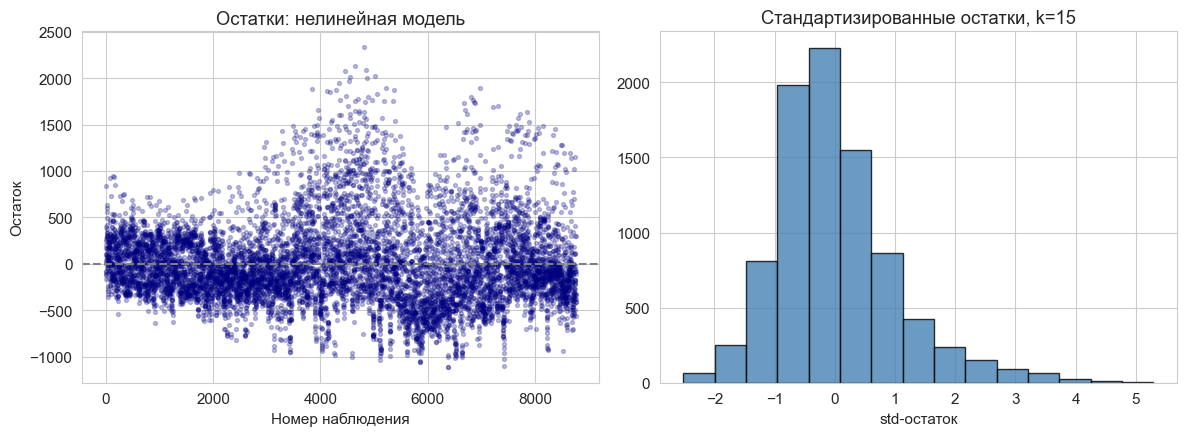

array([ 249.01207861,  200.55540651,  175.03942955, ..., -414.58484449,
       -408.5213716 , -557.05933166])

In [23]:
# 12. Нелинейная модель с фиктивными переменными.
# Элементы Temp² и Hour² входят линейно по коэффициентам (МНК).
# log(Temp) и log(Hour) не используем: температура бывает отрицательной, час бывает 0.
nl_formula = (
    "Rented ~ Temp + I(Temp**2) + Humidity + Hour + I(Hour**2)"
    " + C(Seasons, Treatment(reference='Winter'))"
    " + C(Holiday, Treatment(reference='No Holiday'))"
    " + C(Functioning, Treatment(reference='Yes'))"
)
nl = smf.ols(nl_formula, data=df).fit()
print("Нелинейная по факторам, линейная по коэффициентам")
ols_quality(nl, "Rented")
residual_report(df[y_name], nl.fittedvalues, "нелинейная модель", ordered=True)


In [24]:
# Сравнение моделей
def row(name, y, fitted, r2, note):
    resid = np.asarray(y) - np.asarray(fitted)
    return {
        "Модель": name,
        "R² или псевдо-R²": r2,
        "СКО остатка": resid.std(ddof=1),
        "Средний |остаток|": np.mean(np.abs(resid)),
        "Комментарий": note,
    }

cmp = pd.DataFrame([
    row("Линейная МНК", df[y_name], lin.fittedvalues, lin.rsquared, "базовая"),
    row("Пуассон ММП", df[y_name], poi.predict(), 1 - poi.llf / poi.llnull, "псевдо-R², не сравнивать с R² напрямую"),
    row("Нелинейная МНК", df[y_name], nl.fittedvalues, nl.rsquared, "Temp², Hour²"),
])
display(cmp.round(3))
print("Линейная и нелинейная модели значимы по F, но R² около 0,53 — ниже порога 0,75.")
print("Квадратичные члены почти не поднимают R², линейной формы по температуре и часу достаточно.")
print("Пуассон соответствует типу отклика (счётчик), но φ >> 1, поэтому условие M = D не выполнено и модель по остаткам хуже, чем кажется по z-тестам.")
print("Эластичность: спрос сильнее всего реагирует на температуру; влажность снижает аренду.")
print("Остатки всех моделей автокоррелированы (почасовой ряд) и гетероскедастичны: качество прогноза ограничено.")


,Модель,R² или псевдо-R²,СКО остатка,Средний |остаток|,Комментарий
0,Линейная МНК,0.532,441.259,330.947,базовая
1,Пуассон ММП,0.628,416.296,283.134,"псевдо-R², не сравнивать с R² напрямую"
2,Нелинейная МНК,0.534,440.454,329.359,"Temp², Hour²"


Линейная и нелинейная модели значимы по F, но R² около 0,53 — ниже порога 0,75.
Квадратичные члены почти не поднимают R², линейной формы по температуре и часу достаточно.
Пуассон соответствует типу отклика (счётчик), но φ >> 1, поэтому условие M = D не выполнено и модель по остаткам хуже, чем кажется по z-тестам.
Эластичность: спрос сильнее всего реагирует на температуру; влажность снижает аренду.
Остатки всех моделей автокоррелированы (почасовой ряд) и гетероскедастичны: качество прогноза ограничено.


## ЛР 1.3. Дисперсионный анализ

Пункты 1–3 выполнены в первой части на Seoul Bike. Отклик — `Rented`. В ЛР 1.1 он не согласуется с нормальным распределением, поэтому параметрический критерий Фишера формально не выполнен, но выборки большие и по сезонам почти равные: ANOVA к этому устойчива. Основной вывод даёт Краскел–Уоллис.

Однофакторный анализ: фактор `Seasons`, четыре готовые градации. Двухфакторный: сезон и время суток. Час — числовая переменная, её режем на четыре равных интервала по 6 часов. Температуру вместе с влажностью не берём: по лекции факторы двухфакторного анализа не должны коррелировать.


Однофакторный ANOVA. H0: средние аренды в четырёх сезонах равны.
H1: хотя бы два сезонных средних различаются. α = 0.05.
Градаций l = 4, объём n = 8760
Градация                n      среднее    дисперсия
Autumn               2184      819.598   423912.486
Spring               2208      730.031   386274.226
Summer               2208     1034.073   476437.828
Winter               2160      225.541    22611.809
Q = 3643934362.763, Q1 (между группами) = 765709006.441, Q2 (внутри) = 2878225356.322
Q1 + Q2 = 3643934362.763
F = (Q1/3) / (Q2/8756) = 776.468
F_крит(0.95; 3, 8756) = 2.606, p = < 1e-300
H0 отвергается: средние градаций различаются, фактор влияет на отклик.
Левена (равенство дисперсий): W = 696.323, p = < 1e-300
Дисперсии групп различаются, условие однородности дисперсий не выполнено.
Краскел–Уоллис: H = 2095.901, χ²_крит(0.95, df=3) = 7.815, p = < 1e-300
H0 Краскела–Уоллиса отвергается: распределения градаций различаются.


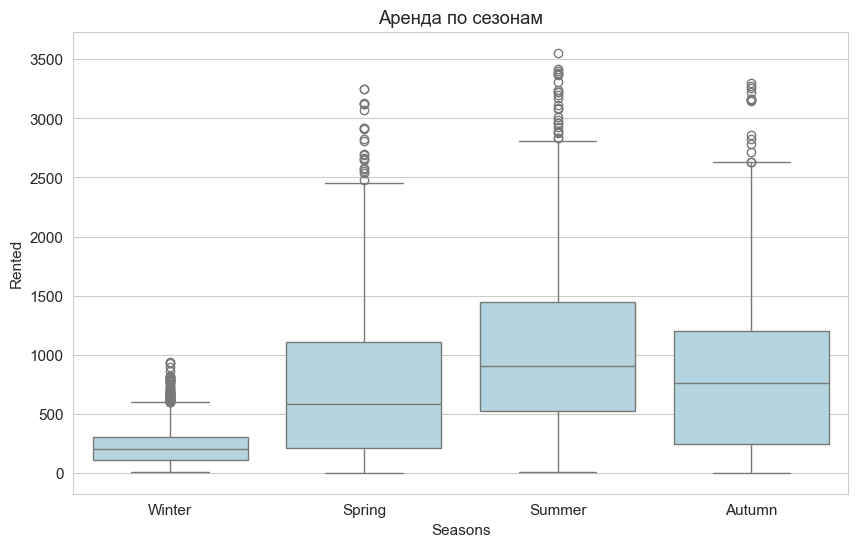

Средние: Winter 226, Spring 730, Summer 1034, Autumn 820
Зимой аренда минимальна (226), летом максимальна (1034).


In [25]:

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

def one_way_anova(frame, y_name, factor):
    grouped = list(frame.groupby(factor, observed=True)[y_name])
    labels = [str(name) for name, _ in grouped]
    samples = [values.to_numpy() for _, values in grouped]
    n = sum(len(s) for s in samples)
    l = len(samples)
    grand = np.concatenate(samples).mean()
    Q = sum(((s - grand) ** 2).sum() for s in samples)
    Q1 = sum(len(s) * (s.mean() - grand) ** 2 for s in samples)
    Q2 = Q - Q1
    d1, d2 = l - 1, n - l
    F = (Q1 / d1) / (Q2 / d2)
    Fcrit = stats.f.ppf(0.95, d1, d2)
    p = stats.f.sf(F, d1, d2)  # survival function точнее, чем 1 − CDF
    print(f"Градаций l = {l}, объём n = {n}")
    print(f"{'Градация':<16} {'n':>8} {'среднее':>12} {'дисперсия':>12}")
    for label, sample in zip(labels, samples):
        print(f"{label:<16} {len(sample):8d} {sample.mean():12.3f} {sample.var(ddof=1):12.3f}")
    print(f"Q = {Q:.3f}, Q1 (между группами) = {Q1:.3f}, Q2 (внутри) = {Q2:.3f}")
    print(f"Q1 + Q2 = {Q1 + Q2:.3f}")
    print(f"F = (Q1/{d1}) / (Q2/{d2}) = {F:.3f}")
    print(f"F_крит(0.95; {d1}, {d2}) = {Fcrit:.3f}, p = {fmt_p(p)}")
    if F > Fcrit:
        print("H0 отвергается: средние градаций различаются, фактор влияет на отклик.")
    else:
        print("H0 не отвергается: влияние фактора не обнаружено.")
    W, p_lev = stats.levene(*samples, center="median")
    print(f"Левена (равенство дисперсий): W = {W:.3f}, p = {fmt_p(p_lev)}")
    if p_lev < 0.05:
        print("Дисперсии групп различаются, условие однородности дисперсий не выполнено.")
    else:
        print("Дисперсии групп можно считать равными.")
    H, p_kw = stats.kruskal(*samples)
    chi_crit = stats.chi2.ppf(0.95, d1)
    print(f"Краскел–Уоллис: H = {H:.3f}, χ²_крит(0.95, df={d1}) = {chi_crit:.3f}, p = {fmt_p(p_kw)}")
    if H > chi_crit:
        print("H0 Краскела–Уоллиса отвергается: распределения градаций различаются.")
    else:
        print("H0 Краскела–Уоллиса не отвергается.")
    return labels, samples

def two_way(frame, y_name, formula, factor_a, factor_b):
    counts = pd.crosstab(frame[factor_a], frame[factor_b])
    print("Число наблюдений в ячейках:")
    display(counts)
    n_min, n_max = counts.to_numpy().min(), counts.to_numpy().max()
    if n_min == n_max:
        print("Комплекс сбалансирован: в ячейках поровну наблюдений.")
    else:
        print(f"Комплекс не сбалансирован (от {n_min} до {n_max}). Считаем Type II ANOVA.")
    model = ols(formula, data=frame).fit()
    table = sm.stats.anova_lm(model, typ=2)
    dfd = table.loc["Residual", "df"]
    print(f"\n{'Источник':<40} {'SS':>14} {'df':>8} {'F':>10} {'F_крит':>10} {'p':>12}")
    for name, row in table.iterrows():
        if name == "Residual":
            print(f"{'Остаток':<40} {row['sum_sq']:14.1f} {row['df']:8.0f}")
            continue
        fcrit = stats.f.ppf(0.95, row["df"], dfd)
        verdict = "влияет" if row["F"] > fcrit else "не влияет"
        print(f"{name:<40} {row['sum_sq']:14.1f} {row['df']:8.0f} {row['F']:10.2f} {fcrit:10.3f} {fmt_p(row['PR(>F)']):>12}  {verdict}")
    return model

print("Однофакторный ANOVA. H0: средние аренды в четырёх сезонах равны.")
print("H1: хотя бы два сезонных средних различаются. α = 0.05.")
one_way_anova(df, "Rented", "Seasons")
order = ["Winter", "Spring", "Summer", "Autumn"]
sns.boxplot(data=df, x="Seasons", y="Rented", order=order, color="lightblue")
plt.title("Аренда по сезонам")
plt.show()
means = df.groupby("Seasons")["Rented"].mean().reindex(order)
print("Средние:", ", ".join(f"{k} {v:.0f}" for k, v in means.items()))
print(f"Зимой аренда минимальна ({means['Winter']:.0f}), летом максимальна ({means['Summer']:.0f}).")


Hour разбит на интервалы [0,6), [6,12), [12,18), [18,24): равная длина и не меньше двух градаций.
H0 по отдельности: сезон не влияет; время суток не влияет; взаимодействия нет.
Число наблюдений в ячейках:


DayPart,Ночь,Утро,День,Вечер
Seasons,,,,
Autumn,546,546,546,546
Spring,552,552,552,552
Summer,552,552,552,552
Winter,540,540,540,540


Комплекс не сбалансирован (от 540 до 552). Считаем Type II ANOVA.

Источник                                             SS       df          F     F_крит            p
C(Seasons)                                  765709006.4        3    1143.16      2.606     < 1e-300  влияет
C(DayPart)                                  723448654.5        3    1080.07      2.606     < 1e-300  влияет
C(Seasons):C(DayPart)                       202479668.1        9     100.76      1.881  5.2266e-180  влияет
Остаток                                    1952297033.7     8744


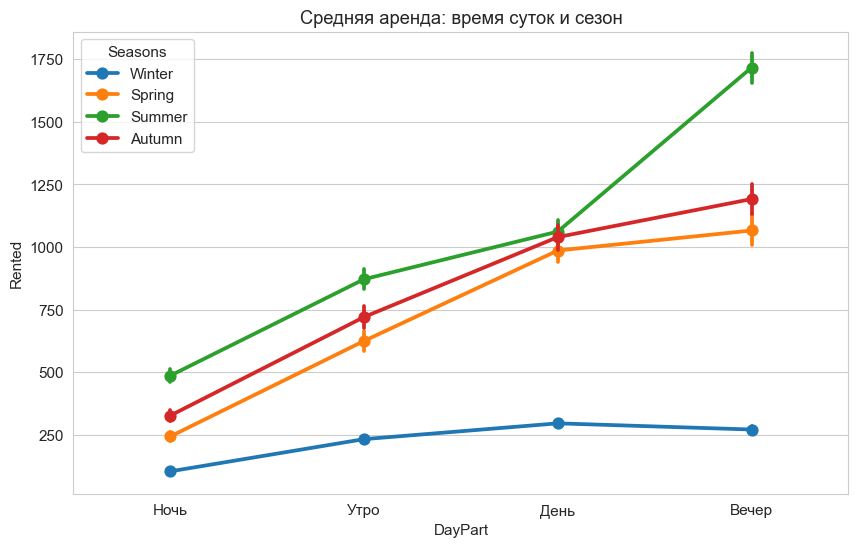

Оба фактора значимы. Взаимодействие тоже: суточный профиль аренды зависит от сезона.
Краскел–Уоллис и Фишер по сезону согласованы: сезон влияет на число аренд.


In [26]:
# 10. Двухфакторный анализ: сезон и время суток
df["DayPart"] = pd.cut(
    df["Hour"], bins=[-0.1, 6, 12, 18, 24],
    labels=["Ночь", "Утро", "День", "Вечер"], right=False,
)
print("Hour разбит на интервалы [0,6), [6,12), [12,18), [18,24): равная длина и не меньше двух градаций.")
print("H0 по отдельности: сезон не влияет; время суток не влияет; взаимодействия нет.")
two_way(
    df, "Rented",
    "Rented ~ C(Seasons) + C(DayPart) + C(Seasons):C(DayPart)",
    "Seasons", "DayPart",
)
sns.pointplot(data=df, x="DayPart", y="Rented", hue="Seasons",
              hue_order=["Winter", "Spring", "Summer", "Autumn"],
              errorbar=("ci", 95))
plt.title("Средняя аренда: время суток и сезон")
plt.show()
print("Оба фактора значимы. Взаимодействие тоже: суточный профиль аренды зависит от сезона.")
print("Краскел–Уоллис и Фишер по сезону согласованы: сезон влияет на число аренд.")
